# MSE802 Assessment 2 — Task 4: Quantum Machine Learning

**Student:** ____________________  
**Runtime:** local Python 3.11 / Qiskit Aer, with optional Quokka validation

This notebook adapts the course-supplied `Quantum_ML_AS2.ipynb` to a local,
reproducible workflow. It analyses the image-classification circuit and its
input, records optimization metric and timing, and compares the quantum model
with a completely classical baseline.

## 1. Environment and reproducibility

The supplied notebook imported `google.colab.files`, used a global NumPy random
state, and hard-coded an unencrypted Quokka URL. This version uses the locked
project environment, explicit seeds, project modules, and environment-based
backend configuration.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "Task_4_Quantum_ML":
    ROOT = ROOT.parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qiskit

from mse802.quantum_ml import deterministic_split, generate_bar_stripe_data

SEED = 802
print(f"Qiskit version: {qiskit.__version__}")
print(f"Project root: {ROOT}")
print(f"Reproducibility seed: {SEED}")

Qiskit version: 2.5.1
Project root: D:\workshop\Codex\802-Quantum-Computing
Reproducibility seed: 802


## 2. Binary image dataset

The starter creates all two-bit binary words, repeats each word as rows for
horizontal stripes and as columns for vertical bars, then removes all-black
and all-white images. With side length 2 this leaves exactly four 2×2 images:
two stripes (label 0) and two bars (label 1). Each flattened pixel becomes one
qubit input, so the model uses four qubits.

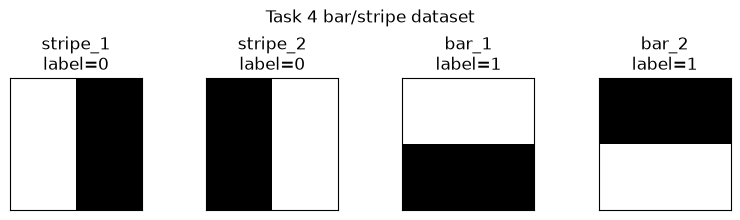

,p0,p1,p2,p3
stripe_1,1.0,0.0,1.0,0.0
stripe_2,0.0,1.0,0.0,1.0
bar_1,1.0,1.0,0.0,0.0
bar_2,0.0,0.0,1.0,1.0


In [2]:
image_data = generate_bar_stripe_data(side_length=2)
dataset = image_data.features
labels = image_data.labels

figure, axes = plt.subplots(1, len(dataset), figsize=(8, 2.2))
for axis, pixels, label, name in zip(
    axes, dataset, labels, image_data.names, strict=True
):
    axis.imshow(pixels.reshape(2, 2), cmap="gray", vmin=0, vmax=1)
    axis.set_title(f"{name}\nlabel={label}")
    axis.set_xticks([])
    axis.set_yticks([])
figure.suptitle("Task 4 bar/stripe dataset")
plt.tight_layout()
plt.show()

pd.DataFrame(dataset, index=image_data.names, columns=["p0", "p1", "p2", "p3"])

## 3. Deterministic starter split

The original 75/25 split was different on every run. A local
`numpy.random.Generator` seeded with 802 preserves the same split rule while
making the selected indices auditable. Because four samples yield only one
test sample, later effectiveness claims also report full-dataset and
leave-one-out measures; the single test item is not treated as a reliable
generalisation estimate.

In [3]:
split = deterministic_split(dataset, labels, seed=SEED)
training, training_labels = split.training, split.training_labels
test, test_labels = split.test, split.test_labels

print("Training indices:", split.training_indices.tolist())
print("Training labels:", training_labels.tolist())
print("Test indices:", split.test_indices.tolist())
print("Test labels:", test_labels.tolist())

assert split.training_indices.tolist() == [3, 0, 2]
assert split.test_indices.tolist() == [1]
assert set(training_labels) == {0, 1}
print("Deterministic split checks: PASS")

Training indices: [3, 0, 2]
Training labels: [1, 0, 1]
Test indices: [1]
Test labels: [0]
Deterministic split checks: PASS


## 4. Circuit and input analysis

The recursive circuit and exact input location are completed in the next
milestone.

## 5. Switchable quantum backend

Local Aer execution and optional Quokka validation are completed after the
circuit is verified.

## 6. Optimization trace

Per-iteration objective values and elapsed times are added with two required
plots.

## 7. Classical no-circuit baseline

A model with no quantum circuit or quantum simulator is added for a fair
efficiency/effectiveness comparison.

## 8. Results, limitations, and conclusion

Benchmark evidence and interpretation are added after both implementations
are complete.